(128, 128)


(-0.5, 127.5, 127.5, -0.5)

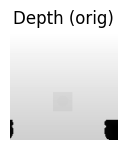

In [21]:
import numpy as np
import matplotlib.pyplot as plt

txt_path = "/home/zsh/MVDA/depth.txt"
out_path = "/home/zsh/MVDA/depth.npy"

arr = np.loadtxt(txt_path, dtype=np.float32)

arr = arr.reshape(128, 128)
arr = arr[::-1, :]
np.save(out_path, arr)
print(arr.shape)
plt.subplot(1, 4, 2)
plt.title('Depth (orig)')
plt.imshow(arr, cmap='gray')
plt.axis('off')



Change

camera shift: 0.08 0
saved: /home/zsh/MVDA/rgb_new.png


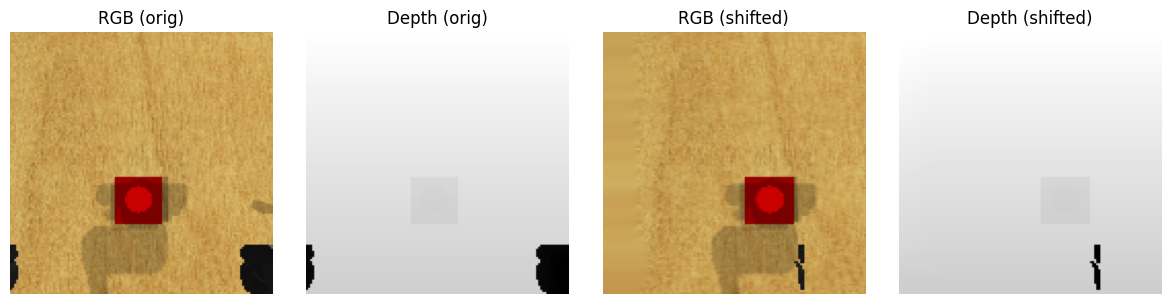

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2

# =========================
# 1. Load depth & RGB
# =========================

# depth = np.load(
#     '/home/zsh/rlbench_demos/tmp/push_button/variation0/episodes/episode1/wrist_depth/0050.npy'
# )

depth = np.load(
    '/home/zsh/MVDA/depth.npy'
)


# rgb = cv2.imread(
#     '/home/zsh/rlbench_demos/tmp/push_button/variation0/episodes/episode1/wrist_rgb/50.png'
# )
rgb = cv2.imread(
    '/home/zsh/MVDA/rgb.png'
)

rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)

H, W = depth.shape

# =========================
# 2. Camera intrinsics
# =========================

K = [[-110.85124795,    0.0,        64.0],
     [   0.0,       -110.85124795,  64.0],
     [   0.0,          0.0,          1.0]]

fx = -K[0][0]
fy = -K[1][1]
cx = K[0][2]
cy = K[1][2]

# =========================
# 3. Camera translation
# =========================

delta_X = random.uniform(-0.02, 0.02)
delta_Y = random.uniform(-0.02, 0.02)
delta_X = 0.08
delta_Y = 0

print('camera shift:', delta_X, delta_Y)

# =========================
# 4. Init splat buffers
# =========================

# RGB
rgb_acc    = np.zeros((H, W, 3), dtype=np.float32)
rgb_wacc   = np.zeros((H, W), dtype=np.float32)

# Depth (inverse depth)
invz_acc   = np.zeros((H, W), dtype=np.float32)
invz_wacc  = np.zeros((H, W), dtype=np.float32)

# z-buffer for visibility (still needed)
zbuf = np.full((H, W), np.inf, dtype=np.float32)

# =========================
# 5. Forward splatting
# =========================

for v in range(H):
    for u in range(W):
        Z = depth[v, u]
        if not np.isfinite(Z) or Z <= 0:
            continue

        # back-project
        X = (u - cx) * Z / fx
        Y = (v - cy) * Z / fy

        # camera translation
        Xn = X + delta_X
        Yn = Y + delta_Y
        Zn = Z

        # project
        uf = fx * Xn / Zn + cx
        vf = fy * Yn / Zn + cy

        u0 = int(np.floor(uf))
        v0 = int(np.floor(vf))
        du = uf - u0
        dv = vf - v0

        color = rgb[v, u]
        invZ  = 1.0 / Zn

        weights = [
            (u0,   v0,   (1-du)*(1-dv)),
            (u0+1, v0,   du*(1-dv)),
            (u0,   v0+1, (1-du)*dv),
            (u0+1, v0+1, du*dv)
        ]

        for ui, vi, w in weights:
            if 0 <= ui < W and 0 <= vi < H and w > 0:
                # visibility check
                if Zn < zbuf[vi, ui] + 1e-4:
                    zbuf[vi, ui] = Zn

                    # RGB splat
                    rgb_acc[vi, ui]  += color * w
                    rgb_wacc[vi, ui] += w

                    # inverse-depth splat
                    invz_acc[vi, ui]  += invZ * w
                    invz_wacc[vi, ui] += w

# =========================
# 6. Normalize RGB
# =========================

rgb_new = np.zeros_like(rgb_acc)
valid_rgb = rgb_wacc > 1e-6
rgb_new[valid_rgb] = rgb_acc[valid_rgb] / rgb_wacc[valid_rgb, None]
rgb_new = np.clip(rgb_new, 0, 255).astype(np.uint8)

# =========================
# 7. Recover depth
# =========================

depth_new = np.zeros((H, W), dtype=np.float32)
valid_d = invz_wacc > 1e-6
depth_new[valid_d] = invz_wacc[valid_d] / invz_acc[valid_d]

# optional clamp
depth_new[depth_new > 8.0] = 0.0

# =========================
# 8. Fill holes (optional)
# =========================

hole_mask = (~valid_d).astype(np.uint8) * 255

rgb_new   = cv2.inpaint(rgb_new, hole_mask, 3, cv2.INPAINT_NS)
depth_new = cv2.inpaint(depth_new, hole_mask, 3, cv2.INPAINT_NS)

# =========================
# 9. Visualization
# =========================

plt.figure(figsize=(12, 3))

plt.subplot(1, 4, 1)
plt.title('RGB (orig)')
plt.imshow(rgb)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title('Depth (orig)')
plt.imshow(depth, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title('RGB (shifted)')
plt.imshow(rgb_new)
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title('Depth (shifted)')
plt.imshow(depth_new, cmap='gray')
plt.axis('off')
# 保存 rgb_new 为 PNG
from PIL import Image

out_path = "/home/zsh/MVDA/rgb_new.png"
Image.fromarray(rgb_new).save(out_path)
print("saved:", out_path)
plt.tight_layout()
plt.show()


Change back

camera shift: -0.0014063938579372617 0.017336204808405968


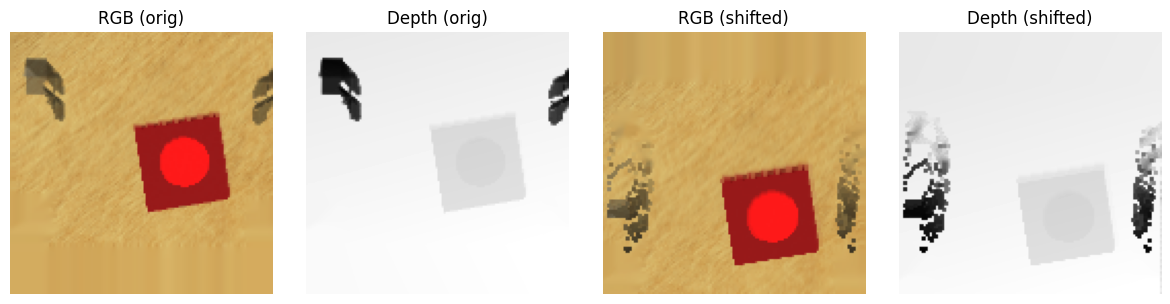

In [7]:
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2

# =========================
# 1. Load depth & RGB
# =========================

depth = depth_new

rgb = rgb_new

H, W = depth.shape

# =========================
# 2. Camera intrinsics
# =========================

K = [[-110.85124795,    0.0,        64.0],
     [   0.0,       -110.85124795,  64.0],
     [   0.0,          0.0,          1.0]]

fx = -K[0][0]
fy = -K[1][1]
cx = K[0][2]
cy = K[1][2]

# =========================
# 3. Camera translation
# =========================

delta_X = -delta_X
delta_Y = -delta_Y
print('camera shift:', delta_X, delta_Y)

# =========================
# 4. Init splat buffers
# =========================

# RGB
rgb_acc    = np.zeros((H, W, 3), dtype=np.float32)
rgb_wacc   = np.zeros((H, W), dtype=np.float32)

# Depth (inverse depth)
invz_acc   = np.zeros((H, W), dtype=np.float32)
invz_wacc  = np.zeros((H, W), dtype=np.float32)

# z-buffer for visibility (still needed)
zbuf = np.full((H, W), np.inf, dtype=np.float32)

# =========================
# 5. Forward splatting
# =========================

for v in range(H):
    for u in range(W):
        Z = depth[v, u]
        if not np.isfinite(Z) or Z <= 0:
            continue

        # back-project
        X = (u - cx) * Z / fx
        Y = (v - cy) * Z / fy

        # camera translation
        Xn = X + delta_X
        Yn = Y + delta_Y
        Zn = Z

        # project
        uf = fx * Xn / Zn + cx
        vf = fy * Yn / Zn + cy

        u0 = int(np.floor(uf))
        v0 = int(np.floor(vf))
        du = uf - u0
        dv = vf - v0

        color = rgb[v, u]
        invZ  = 1.0 / Zn

        weights = [
            (u0,   v0,   (1-du)*(1-dv)),
            (u0+1, v0,   du*(1-dv)),
            (u0,   v0+1, (1-du)*dv),
            (u0+1, v0+1, du*dv)
        ]

        for ui, vi, w in weights:
            if 0 <= ui < W and 0 <= vi < H and w > 0:
                # visibility check
                if Zn < zbuf[vi, ui] + 1e-4:
                    zbuf[vi, ui] = Zn

                    # RGB splat
                    rgb_acc[vi, ui]  += color * w
                    rgb_wacc[vi, ui] += w

                    # inverse-depth splat
                    invz_acc[vi, ui]  += invZ * w
                    invz_wacc[vi, ui] += w

# =========================
# 6. Normalize RGB
# =========================

rgb_new = np.zeros_like(rgb_acc)
valid_rgb = rgb_wacc > 1e-6
rgb_new[valid_rgb] = rgb_acc[valid_rgb] / rgb_wacc[valid_rgb, None]
rgb_new = np.clip(rgb_new, 0, 255).astype(np.uint8)

# =========================
# 7. Recover depth
# =========================

depth_new = np.zeros((H, W), dtype=np.float32)
valid_d = invz_wacc > 1e-6
depth_new[valid_d] = invz_wacc[valid_d] / invz_acc[valid_d]

# optional clamp
depth_new[depth_new > 8.0] = 0.0

# =========================
# 8. Fill holes (optional)
# =========================

hole_mask = (~valid_d).astype(np.uint8) * 255

rgb_new   = cv2.inpaint(rgb_new, hole_mask, 3, cv2.INPAINT_NS)
depth_new = cv2.inpaint(depth_new, hole_mask, 3, cv2.INPAINT_NS)

# =========================
# 9. Visualization
# =========================

plt.figure(figsize=(12, 3))

plt.subplot(1, 4, 1)
plt.title('RGB (orig)')
plt.imshow(rgb)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title('Depth (orig)')
plt.imshow(depth, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title('RGB (shifted)')
plt.imshow(rgb_new)
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title('Depth (shifted)')
plt.imshow(depth_new, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


Double time

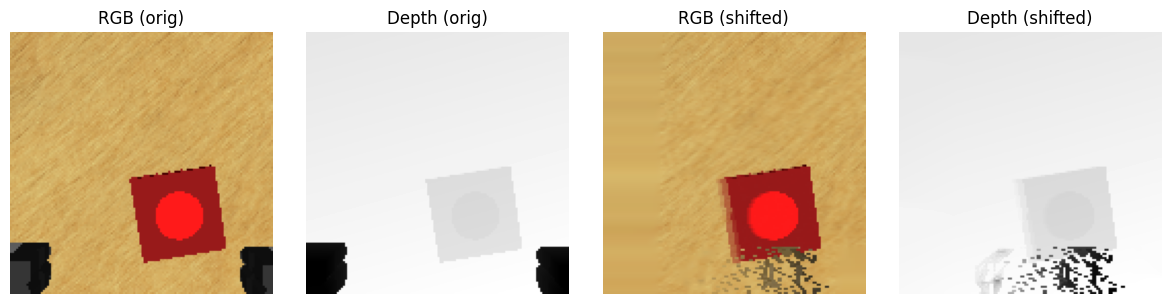

In [12]:
import numpy as np
import lmdb
import random
import io
import shutil
import re
import random
import numpy as np
import cv2
import pickle
import os
from PIL import Image

# os.environ["QT_QPA_PLATFORM"] = "offscreen"

def get_changed_rgb(depth_path, rgb_path, pkl_path, delta_X, delta_Y):
    # load depth
    depth = np.load(depth_path)
    rgb = cv2.imread(rgb_path)
    rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)

    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    obs = data[0]
    K = obs.misc['wrist_camera_intrinsics']
    fx = -K[0][0]
    fy = -K[1][1]
    cx = K[0][2]
    cy = K[1][2]

    # print(delta_X, delta_Y)
    H, W = depth.shape
    # RGB
    rgb_acc    = np.zeros((H, W, 3), dtype=np.float32)
    rgb_wacc   = np.zeros((H, W), dtype=np.float32)

    # Depth (inverse depth)
    invz_acc   = np.zeros((H, W), dtype=np.float32)
    invz_wacc  = np.zeros((H, W), dtype=np.float32)

    # z-buffer for visibility (still needed)
    zbuf = np.full((H, W), np.inf, dtype=np.float32)

    # =========================
    # 5. Forward splatting
    # =========================

    for v in range(H):
        for u in range(W):
            Z = depth[v, u]
            if not np.isfinite(Z) or Z <= 0:
                continue

            # back-project
            X = (u - cx) * Z / fx
            Y = (v - cy) * Z / fy

            # camera translation
            Xn = X + delta_X
            Yn = Y + delta_Y
            Zn = Z

            # project
            uf = fx * Xn / Zn + cx
            vf = fy * Yn / Zn + cy

            u0 = int(np.floor(uf))
            v0 = int(np.floor(vf))
            du = uf - u0
            dv = vf - v0

            color = rgb[v, u]
            invZ  = 1.0 / Zn

            weights = [
                (u0,   v0,   (1-du)*(1-dv)),
                (u0+1, v0,   du*(1-dv)),
                (u0,   v0+1, (1-du)*dv),
                (u0+1, v0+1, du*dv)
            ]

            for ui, vi, w in weights:
                if 0 <= ui < W and 0 <= vi < H and w > 0:
                    # visibility check
                    if Zn < zbuf[vi, ui] + 1e-4:
                        zbuf[vi, ui] = Zn

                        # RGB splat
                        rgb_acc[vi, ui]  += color * w
                        rgb_wacc[vi, ui] += w

                        # inverse-depth splat
                        invz_acc[vi, ui]  += invZ * w
                        invz_wacc[vi, ui] += w

    # =========================
    # 6. Normalize RGB
    # =========================

    rgb_new = np.zeros_like(rgb_acc)
    valid_rgb = rgb_wacc > 1e-6
    rgb_new[valid_rgb] = rgb_acc[valid_rgb] / rgb_wacc[valid_rgb, None]
    rgb_new = np.clip(rgb_new, 0, 255).astype(np.uint8)

    # =========================
    # 7. Recover depth
    # =========================

    depth_new = np.zeros((H, W), dtype=np.float32)
    valid_d = invz_wacc > 1e-6
    depth_new[valid_d] = invz_wacc[valid_d] / invz_acc[valid_d]

    # optional clamp
    depth_new[depth_new > 8.0] = 0.0

    # =========================
    # 8. Fill holes (optional)
    # =========================

    hole_mask = (~valid_d).astype(np.uint8) * 255


    rgb_org = rgb
    depth_org = depth
    rgb = rgb_new
    depth = depth_new

    rgb_new   = cv2.inpaint(rgb_new, hole_mask, 3, cv2.INPAINT_NS)
    depth_new = cv2.inpaint(depth_new, hole_mask, 3, cv2.INPAINT_NS)

    depth[depth <= 1e-5] = float('inf')

    delta_X = -delta_X  # 相机沿X轴平移的距离，单位：米
    delta_Y = -delta_Y  # 相机沿Y轴平移的距离，

    # RGB
    rgb_acc    = np.zeros((H, W, 3), dtype=np.float32)
    rgb_wacc   = np.zeros((H, W), dtype=np.float32)

    # Depth (inverse depth)
    invz_acc   = np.zeros((H, W), dtype=np.float32)
    invz_wacc  = np.zeros((H, W), dtype=np.float32)

    # z-buffer for visibility (still needed)
    zbuf = np.full((H, W), np.inf, dtype=np.float32)

    # =========================
    # 5. Forward splatting
    # =========================

    for v in range(H):
        for u in range(W):
            Z = depth[v, u]
            if not np.isfinite(Z) or Z <= 0:
                continue

            # back-project
            X = (u - cx) * Z / fx
            Y = (v - cy) * Z / fy

            # camera translation
            Xn = X + delta_X
            Yn = Y + delta_Y
            Zn = Z

            # project
            uf = fx * Xn / Zn + cx
            vf = fy * Yn / Zn + cy

            u0 = int(np.floor(uf))
            v0 = int(np.floor(vf))
            du = uf - u0
            dv = vf - v0

            color = rgb[v, u]
            invZ  = 1.0 / Zn

            weights = [
                (u0,   v0,   (1-du)*(1-dv)),
                (u0+1, v0,   du*(1-dv)),
                (u0,   v0+1, (1-du)*dv),
                (u0+1, v0+1, du*dv)
            ]

            for ui, vi, w in weights:
                if 0 <= ui < W and 0 <= vi < H and w > 0:
                    # visibility check
                    if Zn < zbuf[vi, ui] + 1e-4:
                        zbuf[vi, ui] = Zn

                        # RGB splat
                        rgb_acc[vi, ui]  += color * w
                        rgb_wacc[vi, ui] += w

                        # inverse-depth splat
                        invz_acc[vi, ui]  += invZ * w
                        invz_wacc[vi, ui] += w

    # =========================
    # 6. Normalize RGB
    # =========================

    rgb_new = np.zeros_like(rgb_acc)
    valid_rgb = rgb_wacc > 1e-6
    rgb_new[valid_rgb] = rgb_acc[valid_rgb] / rgb_wacc[valid_rgb, None]
    rgb_new = np.clip(rgb_new, 0, 255).astype(np.uint8)

    # =========================
    # 7. Recover depth
    # =========================

    depth_new = np.zeros((H, W), dtype=np.float32)
    valid_d = invz_wacc > 1e-6
    depth_new[valid_d] = invz_wacc[valid_d] / invz_acc[valid_d]

    # optional clamp
    depth_new[depth_new > 8.0] = 0.0

    # =========================
    # 8. Fill holes (optional)
    # =========================

    hole_mask = (~valid_d).astype(np.uint8) * 255

    rgb_new   = cv2.inpaint(rgb_new, hole_mask, 3, cv2.INPAINT_NS)
    depth_new = cv2.inpaint(depth_new, hole_mask, 3, cv2.INPAINT_NS)

    return depth_org, rgb_org, depth_new, rgb_new



rgb_path = '/home/zsh/rlbench_demos/tmp/push_button/variation0/episodes/episode1/wrist_rgb/50.png'
depth_path = '/home/zsh/rlbench_demos/tmp/push_button/variation0/episodes/episode1/wrist_depth/0050.npy'
depth_org, rgb_org, depth_new, rgb_new = get_changed_rgb(depth_path, rgb_path, f'/home/zsh/rlbench_demos/train/push_button/variation0/episodes/episode1/low_dim_obs.pkl', -0.02, 0)


plt.figure(figsize=(12, 3))

plt.subplot(1, 4, 1)
plt.title('RGB (orig)')
plt.imshow(rgb_org)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title('Depth (orig)')
plt.imshow(depth_org, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title('RGB (shifted)')
plt.imshow(rgb_new)
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title('Depth (shifted)')
plt.imshow(depth_new, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

Dual Task

0.049220533697918435 1.4814300786395322
camera shift: -0.07831266120444852 0.06081319612957922 0.044205399723551184
camera rotation (deg): 0.49165295465650055 0.4388981300947521 0.33016249156814426


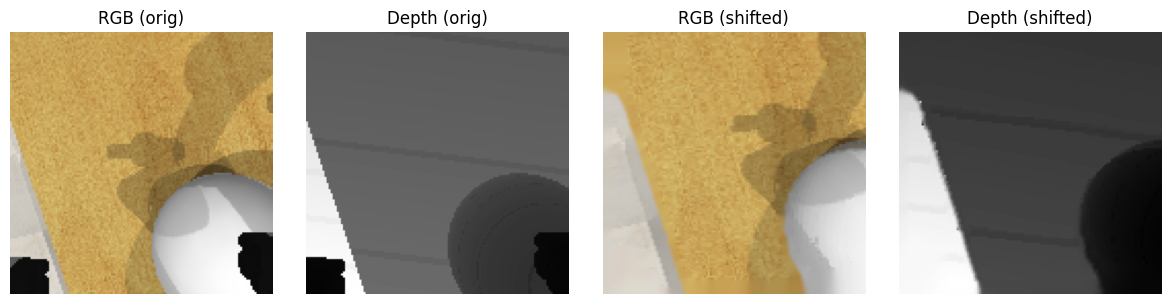

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

import pickle

pkl_path = "/home/zsh/dcoda/data/rlbench_data/train/coordinated_lift_ball_200_demos_128x128/coordinated_lift_ball/all_variations/episodes/episode88/low_dim_obs.pkl"

with open(pkl_path, "rb") as f:
    low_dim = pickle.load(f)
    near = low_dim[20].misc[f'wrist_left_camera_near']
    far = low_dim[20].misc[f'wrist_left_camera_far']

def load_rlbench_depth(path, near=0.01, far=10.0):
    """
    Decode RLBench RGB depth image into metric depth (meters)
    """

    depth_rgb = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    # BGR → RGB
    # depth_rgb = cv2.cvtColor(depth_rgb, cv2.COLOR_BGR2RGB)

    depth_rgb = depth_rgb.astype(np.uint32)

    # 24-bit integer
    depth_int = (
        depth_rgb[:, :, 0] +
        depth_rgb[:, :, 1] * 256 +
        depth_rgb[:, :, 2] * 256 * 256
    )

    depth = depth_int.astype(np.float32) / (256**3 - 1)

    # scale to metric
    depth = near + depth * (far - near)

    return depth

# =========================
# 1. Load depth & RGB
# =========================



depth = load_rlbench_depth(
    '/home/zsh/dcoda/data/rlbench_data/train/coordinated_lift_ball_200_demos_128x128/coordinated_lift_ball/all_variations/episodes/episode88/wrist_left_depth/depth_0020.png',
    near=near,
    far=far
)
print(depth.min(), depth.max())
rgb = cv2.imread(
    '/home/zsh/dcoda/data/rlbench_data/train/coordinated_lift_ball_200_demos_128x128/coordinated_lift_ball/all_variations/episodes/episode88/wrist_left_rgb/rgb_0020.png'
)
rgb   = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)

H, W = depth.shape

# =========================
# 2. Camera intrinsics
# =========================

K = [[-110.85124795,    0.0,        64.0],
     [   0.0,       -110.85124795,  64.0],
     [   0.0,          0.0,          1.0]]

fx = -K[0][0]
fy = -K[1][1]
cx = K[0][2]
cy = K[1][2]

# =========================
# 3. 6DoF Camera Motion
# =========================

# translation (meters)
delta_X = random.uniform(0.04, 0.08) * random.choice([-1, 1])
delta_Y = random.uniform(0.04, 0.08) * random.choice([-1, 1])
delta_Z = random.uniform(0.04, 0.08) * random.choice([-1, 1])

# rotation (degrees)
roll  = np.deg2rad(random.uniform(-0.5, 0.5))    # x-axis
pitch = np.deg2rad(random.uniform(-0.5, 0.5))    # y-axis
yaw   = np.deg2rad(random.uniform(-0.5, 0.5))   # z-axis

print("camera shift:", delta_X, delta_Y, delta_Z)
print("camera rotation (deg):", 
      np.rad2deg(roll), 
      np.rad2deg(pitch), 
      np.rad2deg(yaw))

# =========================
# 4. Euler → Rotation Matrix
# =========================

def euler_to_matrix(roll, pitch, yaw):
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(roll), -np.sin(roll)],
        [0, np.sin(roll),  np.cos(roll)]
    ])

    Ry = np.array([
        [ np.cos(pitch), 0, np.sin(pitch)],
        [0, 1, 0],
        [-np.sin(pitch), 0, np.cos(pitch)]
    ])

    Rz = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])

    return Rz @ Ry @ Rx  # ZYX order

R = euler_to_matrix(roll, pitch, yaw)
t = np.array([delta_X, delta_Y, delta_Z])

# =========================
# 5. Init splat buffers
# =========================

rgb_acc   = np.zeros((H, W, 3), dtype=np.float32)
rgb_wacc  = np.zeros((H, W), dtype=np.float32)

invz_acc  = np.zeros((H, W), dtype=np.float32)
invz_wacc = np.zeros((H, W), dtype=np.float32)

zbuf = np.full((H, W), np.inf, dtype=np.float32)

# =========================
# 6. Forward splatting
# =========================

for v in range(H):
    for u in range(W):

        Z = depth[v, u]
        if not np.isfinite(Z) or Z <= 0:
            continue

        # back-project to 3D
        X = (u - cx) * Z / fx
        Y = (v - cy) * Z / fy

        P = np.array([X, Y, Z])

        # 6DoF transform
        Pn = R @ (P - t)
        Xn, Yn, Zn = Pn

        if Zn <= 0:
            continue

        # re-project
        uf = fx * Xn / Zn + cx
        vf = fy * Yn / Zn + cy

        u0 = int(np.floor(uf))
        v0 = int(np.floor(vf))

        du = uf - u0
        dv = vf - v0

        color = rgb[v, u]
        invZ  = 1.0 / Zn

        weights = [
            (u0,   v0,   (1-du)*(1-dv)),
            (u0+1, v0,   du*(1-dv)),
            (u0,   v0+1, (1-du)*dv),
            (u0+1, v0+1, du*dv)
        ]

        for ui, vi, w in weights:
            if 0 <= ui < W and 0 <= vi < H and w > 0:

                if Zn < zbuf[vi, ui] + 1e-4:
                    zbuf[vi, ui] = Zn

                    rgb_acc[vi, ui]  += color * w
                    rgb_wacc[vi, ui] += w

                    invz_acc[vi, ui]  += invZ * w
                    invz_wacc[vi, ui] += w

# =========================
# 7. Normalize RGB
# =========================

rgb_new = np.zeros_like(rgb_acc)
valid_rgb = rgb_wacc > 1e-6
rgb_new[valid_rgb] = rgb_acc[valid_rgb] / rgb_wacc[valid_rgb, None]
rgb_new = np.clip(rgb_new, 0, 255).astype(np.uint8)

# =========================
# 8. Recover depth
# =========================

depth_new = np.zeros((H, W), dtype=np.float32)
valid_d = invz_wacc > 1e-6
depth_new[valid_d] = invz_wacc[valid_d] / invz_acc[valid_d]

depth_new[depth_new > 8.0] = 0.0

# =========================
# 9. Hole filling
# =========================

hole_mask = (~valid_d).astype(np.uint8) * 255

rgb_new   = cv2.inpaint(rgb_new, hole_mask, 3, cv2.INPAINT_NS)
depth_new = cv2.inpaint(depth_new, hole_mask, 3, cv2.INPAINT_NS)

# =========================
# 10. Save & Visualize
# =========================

Image.fromarray(rgb_new).save("/home/zsh/MVDA/rgb_new.png")
np.save("/home/zsh/MVDA/depth_new.npy", depth_new)

plt.figure(figsize=(12,3))

plt.subplot(1,4,1)
plt.title("RGB (orig)")
plt.imshow(rgb)
plt.axis("off")

plt.subplot(1,4,2)
plt.title("Depth (orig)")
plt.imshow(depth, cmap='gray')
plt.axis("off")

plt.subplot(1,4,3)
plt.title("RGB (shifted)")
plt.imshow(rgb_new)
plt.axis("off")

plt.subplot(1,4,4)
plt.title("Depth (shifted)")
plt.imshow(depth_new, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()